# Microbes identification: Exploratory Data Analysis (EDA)

The aim of this project is to analyze a dataset of ten different microorganisms and develop a multiclass classification model based on their morphological and structural features extracted from microscope images.

# Imports

In [1]:
import pandas as pd

import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Data Loading

In [2]:
df_microbes = pd.read_csv(r"C:\Users\Usuario\Proyectos\Practica\microbes\Data\raw\microbes.csv")
display(df_microbes.head())
print(df_microbes.shape)

,Unnamed: 0,Solidity,Eccentricity,EquivDiameter,Extrema,FilledArea,Extent,Orientation,EulerNumber,BoundingBox1,...,ConvexHull4,MajorAxisLength,MinorAxisLength,Perimeter,ConvexArea,Centroid1,Centroid2,Area,raddi,microorganisms
0,0,10.70,15.8,5.43,3.75,0.785,8.14,2.15,22.3,2.97,...,2.97,1.34,1.61,0.683,0.195,3.63,12.10,1.310,7.99,Spirogyra
1,1,5.60,18.3,4.14,6.16,0.364,3.51,18.60,22.5,5.41,...,5.47,1.52,1.52,1.010,0.215,6.01,20.60,0.765,7.99,Spirogyra
2,2,8.32,19.8,4.63,6.66,0.415,5.85,21.00,22.4,5.96,...,5.96,1.63,1.38,1.110,0.182,6.55,11.50,0.953,7.99,Spirogyra
3,3,10.10,17.9,7.29,11.10,1.470,6.30,9.94,21.9,8.81,...,8.88,2.04,2.12,0.715,0.371,10.30,12.00,2.340,7.99,Spirogyra
4,4,6.27,20.2,20.10,10.70,14.700,3.97,2.58,11.9,10.20,...,10.20,7.78,6.21,6.800,4.440,14.00,9.55,17.600,7.99,Spirogyra


(30527, 26)


# Dataset exploration

In [3]:
display(df_microbes.info())

<class 'pandas.DataFrame'>
RangeIndex: 30527 entries, 0 to 30526
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30527 non-null  int64  
 1   Solidity         30527 non-null  float64
 2   Eccentricity     30527 non-null  float64
 3   EquivDiameter    30527 non-null  float64
 4   Extrema          30527 non-null  float64
 5   FilledArea       30527 non-null  float64
 6   Extent           30527 non-null  float64
 7   Orientation      30527 non-null  float64
 8   EulerNumber      30527 non-null  float64
 9   BoundingBox1     30527 non-null  float64
 10  BoundingBox2     30527 non-null  float64
 11  BoundingBox3     30527 non-null  float64
 12  BoundingBox4     30527 non-null  float64
 13  ConvexHull1      30527 non-null  float64
 14  ConvexHull2      30527 non-null  float64
 15  ConvexHull3      30527 non-null  float64
 16  ConvexHull4      30527 non-null  float64
 17  MajorAxisLength  30527 

None

In [4]:
df_microbes.describe()

,Unnamed: 0,Solidity,Eccentricity,EquivDiameter,Extrema,FilledArea,Extent,Orientation,EulerNumber,BoundingBox1,...,ConvexHull3,ConvexHull4,MajorAxisLength,MinorAxisLength,Perimeter,ConvexArea,Centroid1,Centroid2,Area,raddi
count,30527.00000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,...,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.000000,30527.00000,30527.000000
mean,15263.00000,9.677744,19.466921,3.633348,11.871832,0.420022,5.840625,11.751004,22.380901,10.919027,...,11.046482,11.021988,1.605159,1.014179,0.829416,0.254596,11.752783,11.554286,0.80278,5.214598
std,8812.53017,4.063437,3.479828,2.210851,6.045135,0.875091,3.250999,6.575319,0.962906,6.093280,...,6.089508,6.089467,1.662537,1.224326,1.152165,0.971035,6.029756,5.700637,1.17043,2.805199
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,7631.50000,6.570000,17.300000,2.180000,6.790000,0.093700,3.280000,6.005000,22.300000,5.690000,...,5.790000,5.755000,0.635000,0.421000,0.253000,0.034700,6.570000,7.110000,0.21800,3.080000
50%,15263.00000,9.350000,20.700000,3.380000,12.000000,0.229000,5.260000,12.100000,22.600000,10.900000,...,11.000000,11.000000,1.160000,0.745000,0.518000,0.085700,12.100000,11.200000,0.51400,5.320000
75%,22894.50000,12.600000,22.200000,4.580000,17.200000,0.434500,7.850000,17.200000,22.900000,15.800000,...,15.900000,15.900000,2.070000,1.220000,0.968000,0.200000,16.900000,16.200000,0.93400,7.050000
max,30526.00000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,...,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.00000,23.000000


*Observations* :

There are no null values in any feature.

Features seems to have been capped at a max value of 23.

## Target analysis 

In [5]:
df_microbes['microorganisms'].value_counts()

microorganisms
Ulothrix          7420
Volvox            4320
Aspergillus sp    3888
Protozoa          3888
Yeast             3600
Raizopus          2552
Diatom            1818
Pithophora        1350
Penicillum        1080
Spirogyra          611
Name: count, dtype: int64

Classes in the target variable are unbalanced.

## Correlation Matrix

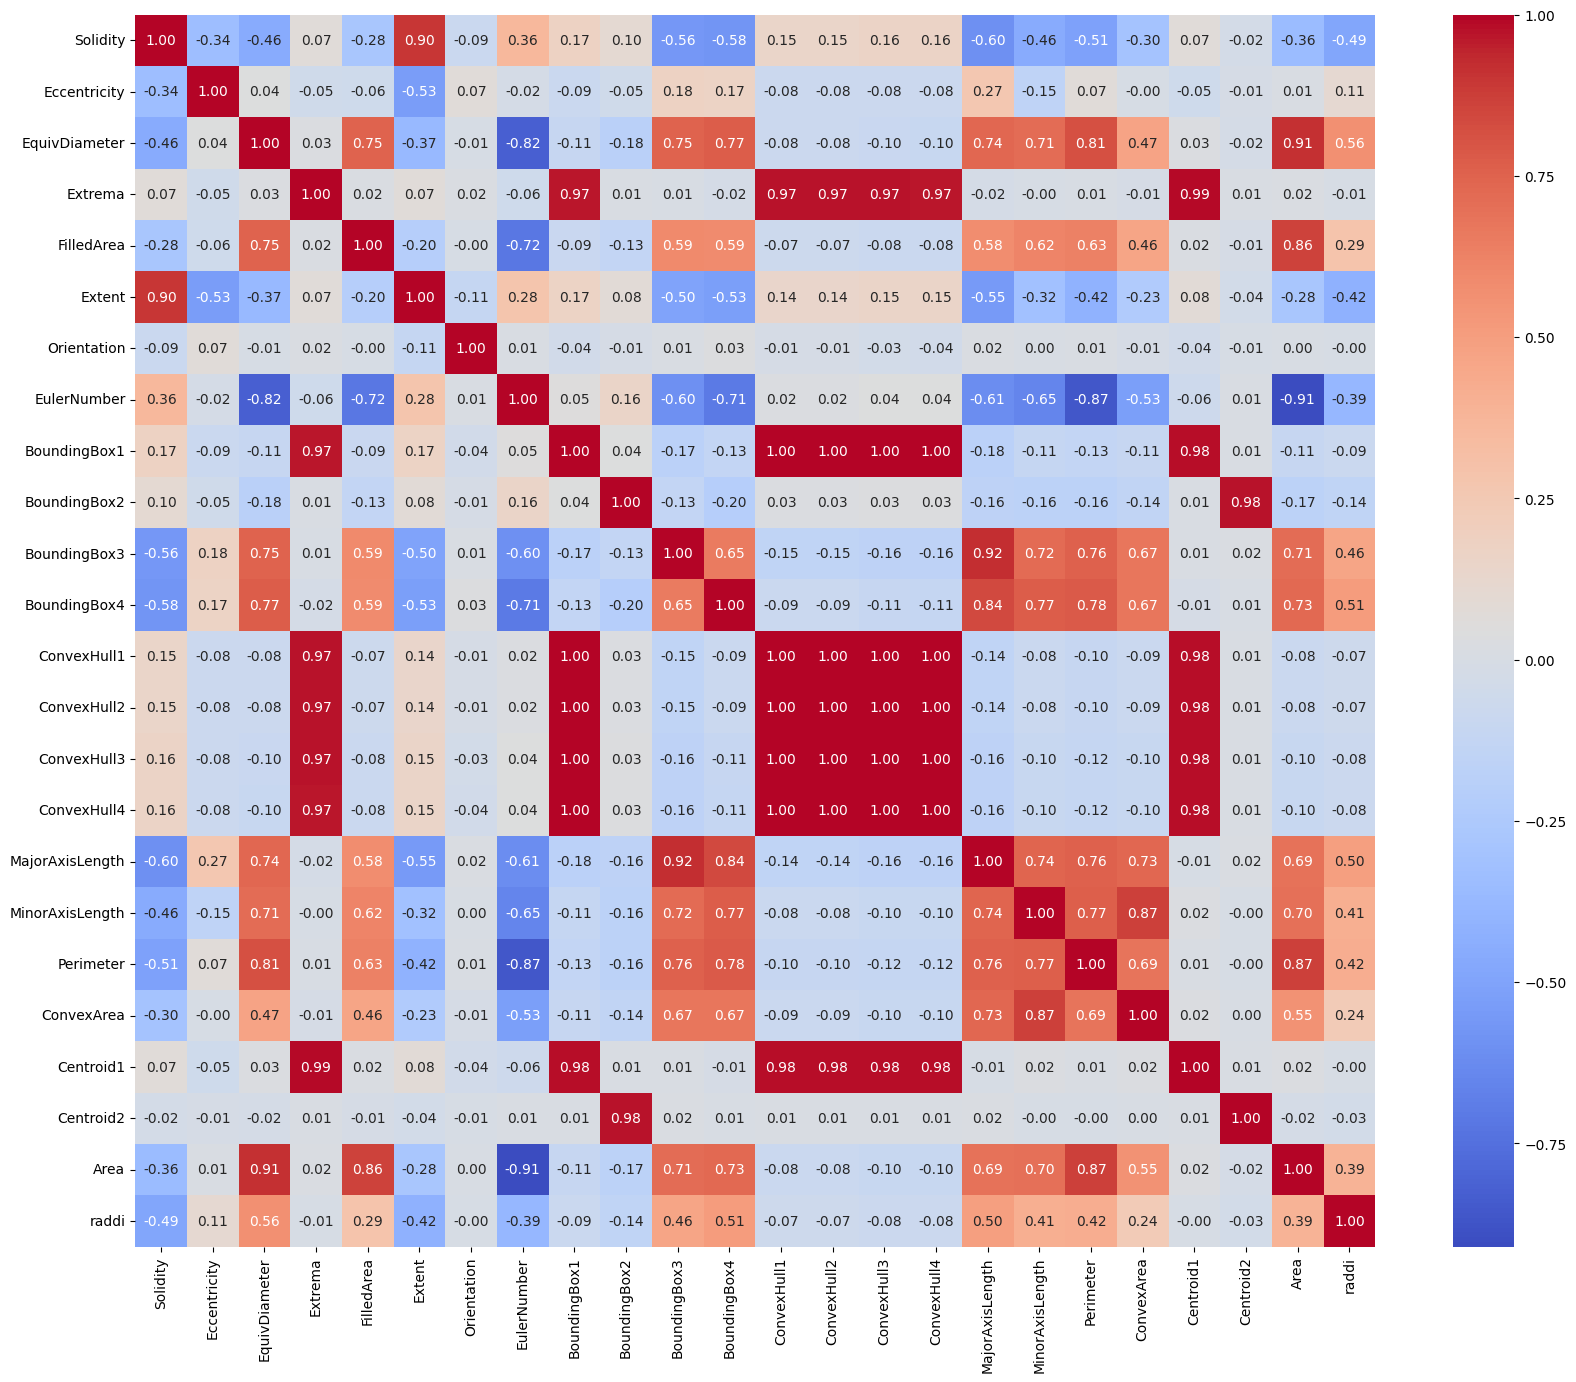

In [6]:
correlación = df_microbes.drop(columns= ['Unnamed: 0', 'microorganisms'])

plt.figure(figsize=(20, 16))
sns.heatmap(correlación.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

There´s redundancy between some of the features, specially ConvexHull1, 2, 3 and 4.

## Feature Distribution

In [7]:
def plot_numerical_distributions(df_data, column_names):
    """
    Genera histogramas con estimación de densidad de kernel (KDE) para múltiples columnas numéricas.
    La función ajusta automáticamente el diseño de la cuadrícula de los gráficos.

    Args:
        df_data (pd.DataFrame): El DataFrame que contiene los datos.
        column_names (list): Una lista de cadenas con los nombres de las columnas a graficar.
    """
    num_plots = len(column_names)

    if num_plots == 0:
        print("No se proporcionaron columnas para graficar.")
        return

    if num_plots == 1:
        nrows, ncols = 1, 1
    elif num_plots == 2:
        nrows, ncols = 1, 2
    else: # For 3 or more plots, aim for 2 columns per row
        nrows = (num_plots + 1) // 2
        ncols = 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    fig.suptitle('Feature Distribution', fontsize=16)

    # Aplanar los ejes para facilitar la iteración si hay múltiples filas/columnas
    if num_plots == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i, col in enumerate(column_names):
        if i < len(axes_flat):
            sns.histplot(df_data[col], kde=True, ax=axes_flat[i], color='teal')
            axes_flat[i].set_title(f'{col} distribution')
            axes_flat[i].set_xlabel(col)
            axes_flat[i].set_ylabel('Frecuency')

    # Ocultar ejes vacíos si los hay
    for j in range(num_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [8]:
df_microbes.columns

Index(['Unnamed: 0', 'Solidity', 'Eccentricity', 'EquivDiameter', 'Extrema',
       'FilledArea', 'Extent', 'Orientation', 'EulerNumber', 'BoundingBox1',
       'BoundingBox2', 'BoundingBox3', 'BoundingBox4', 'ConvexHull1',
       'ConvexHull2', 'ConvexHull3', 'ConvexHull4', 'MajorAxisLength',
       'MinorAxisLength', 'Perimeter', 'ConvexArea', 'Centroid1', 'Centroid2',
       'Area', 'raddi', 'microorganisms'],
      dtype='str')

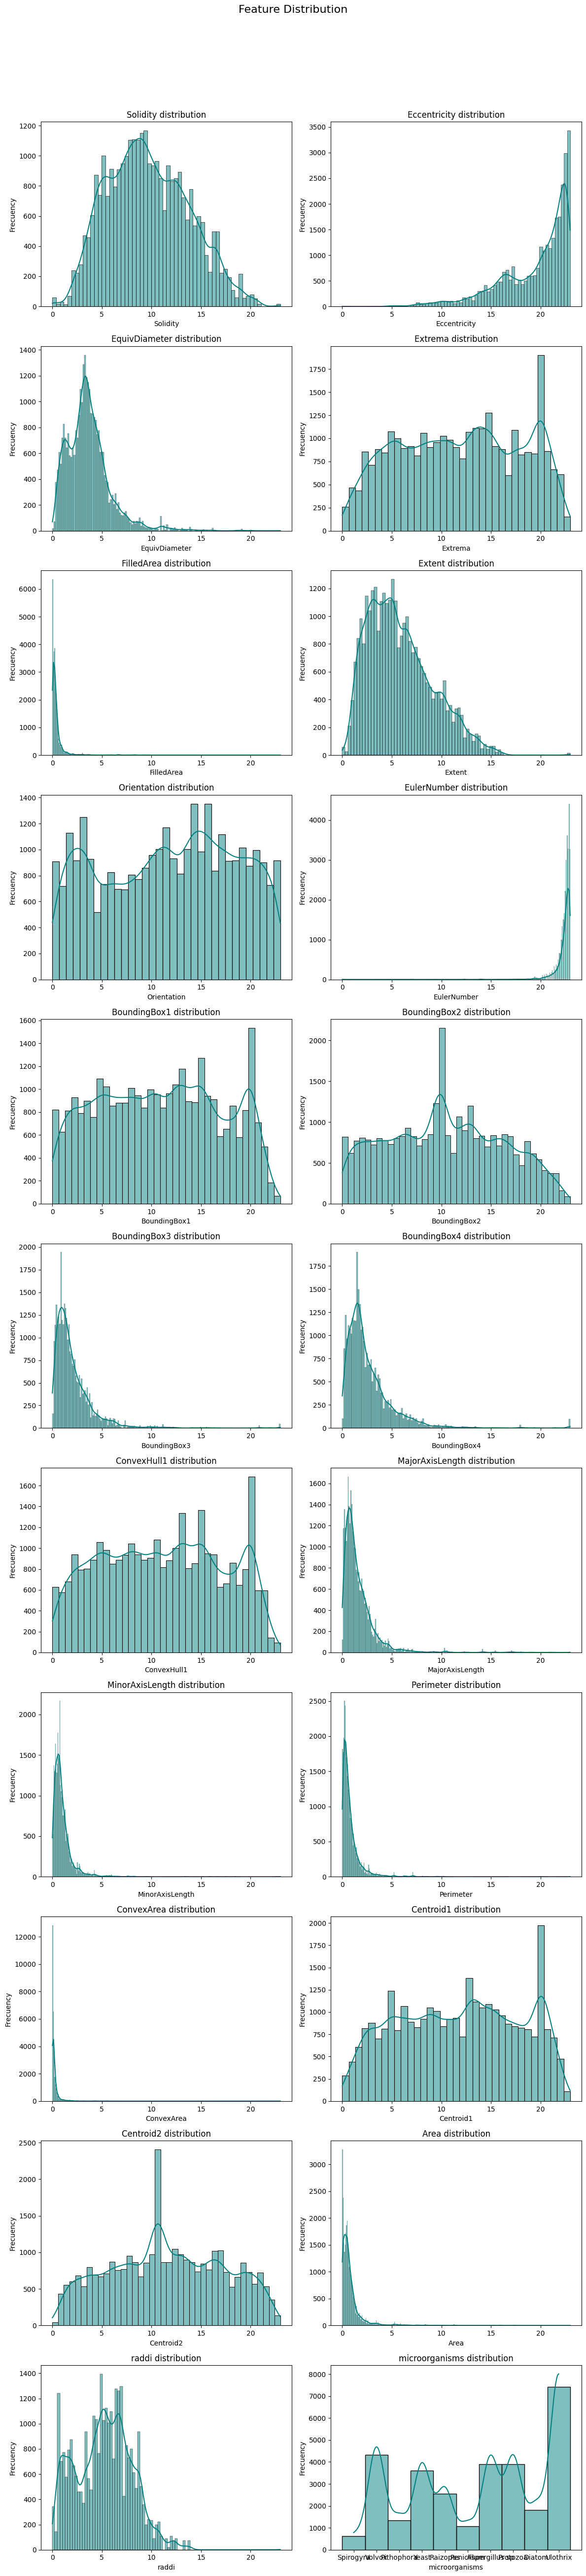

In [9]:
plot_numerical_distributions(df_microbes, ['Solidity', 'Eccentricity', 'EquivDiameter', 'Extrema', 'FilledArea',
       'Extent', 'Orientation', 'EulerNumber', 'BoundingBox1', 'BoundingBox2',
       'BoundingBox3', 'BoundingBox4', 'ConvexHull1', 'MajorAxisLength',
       'MinorAxisLength', 'Perimeter', 'ConvexArea', 'Centroid1', 'Centroid2',
       'Area', 'raddi', 'microorganisms'])

## Correlation Matrix / Including each Class from Target

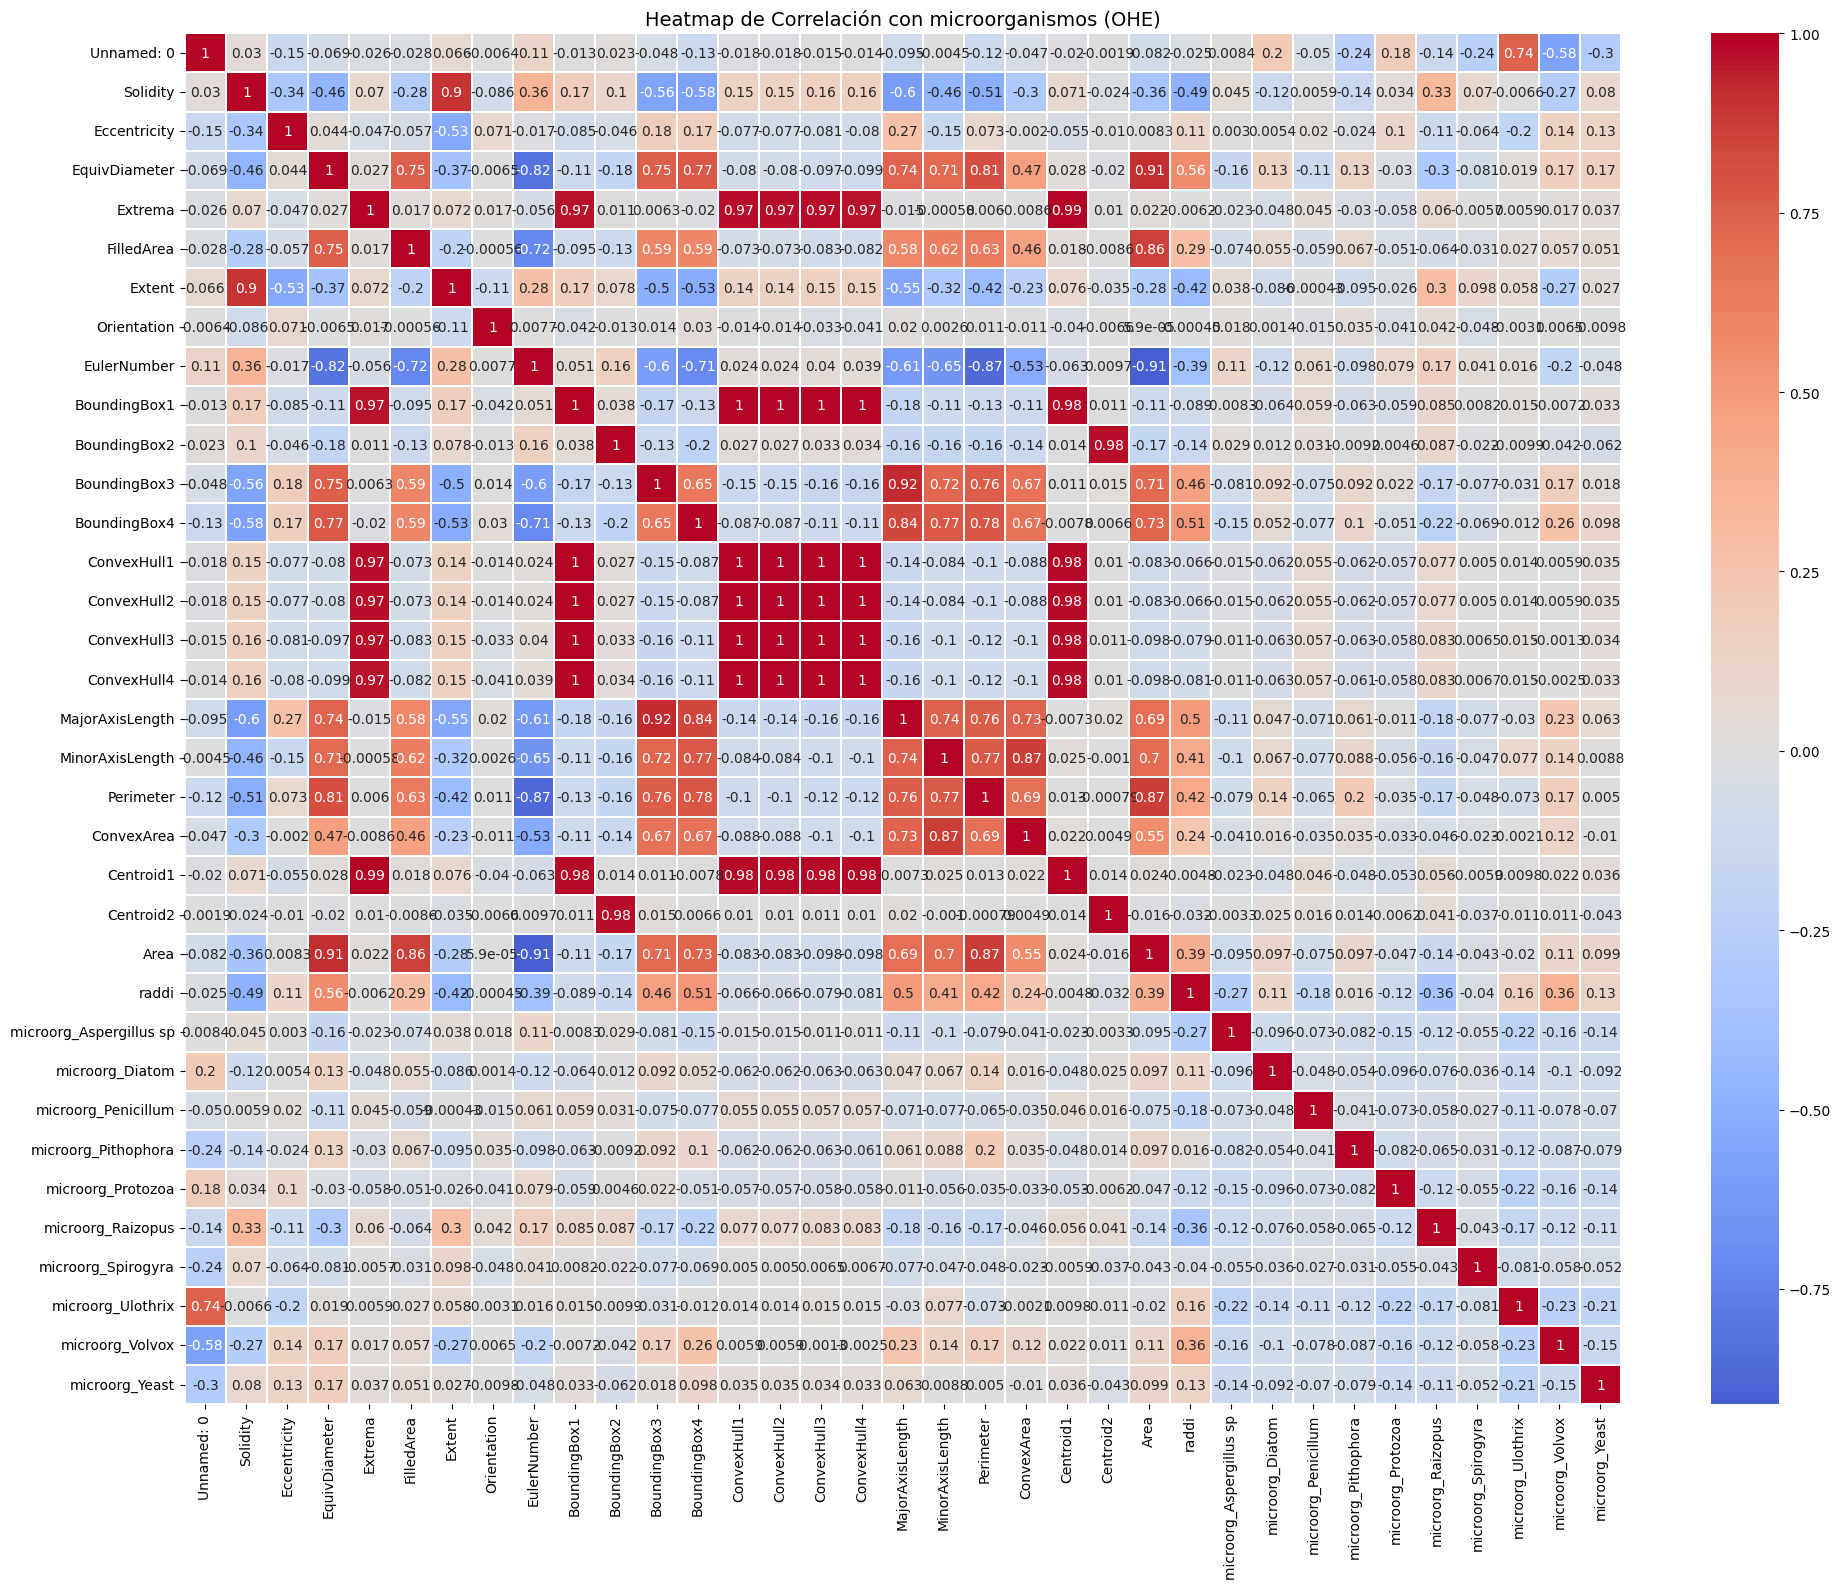

In [10]:

df = df_microbes.copy()
ohe = pd.get_dummies(df['microorganisms'], prefix='microorg')

df_ohe = pd.concat([df.drop(columns='microorganisms'), ohe], axis=1)

plt.figure(figsize=(20, 16))
sns.heatmap(
    df_ohe.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=True  
)
plt.title('Heatmap de Correlación con microorganismos (OHE)', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Outliers analysis

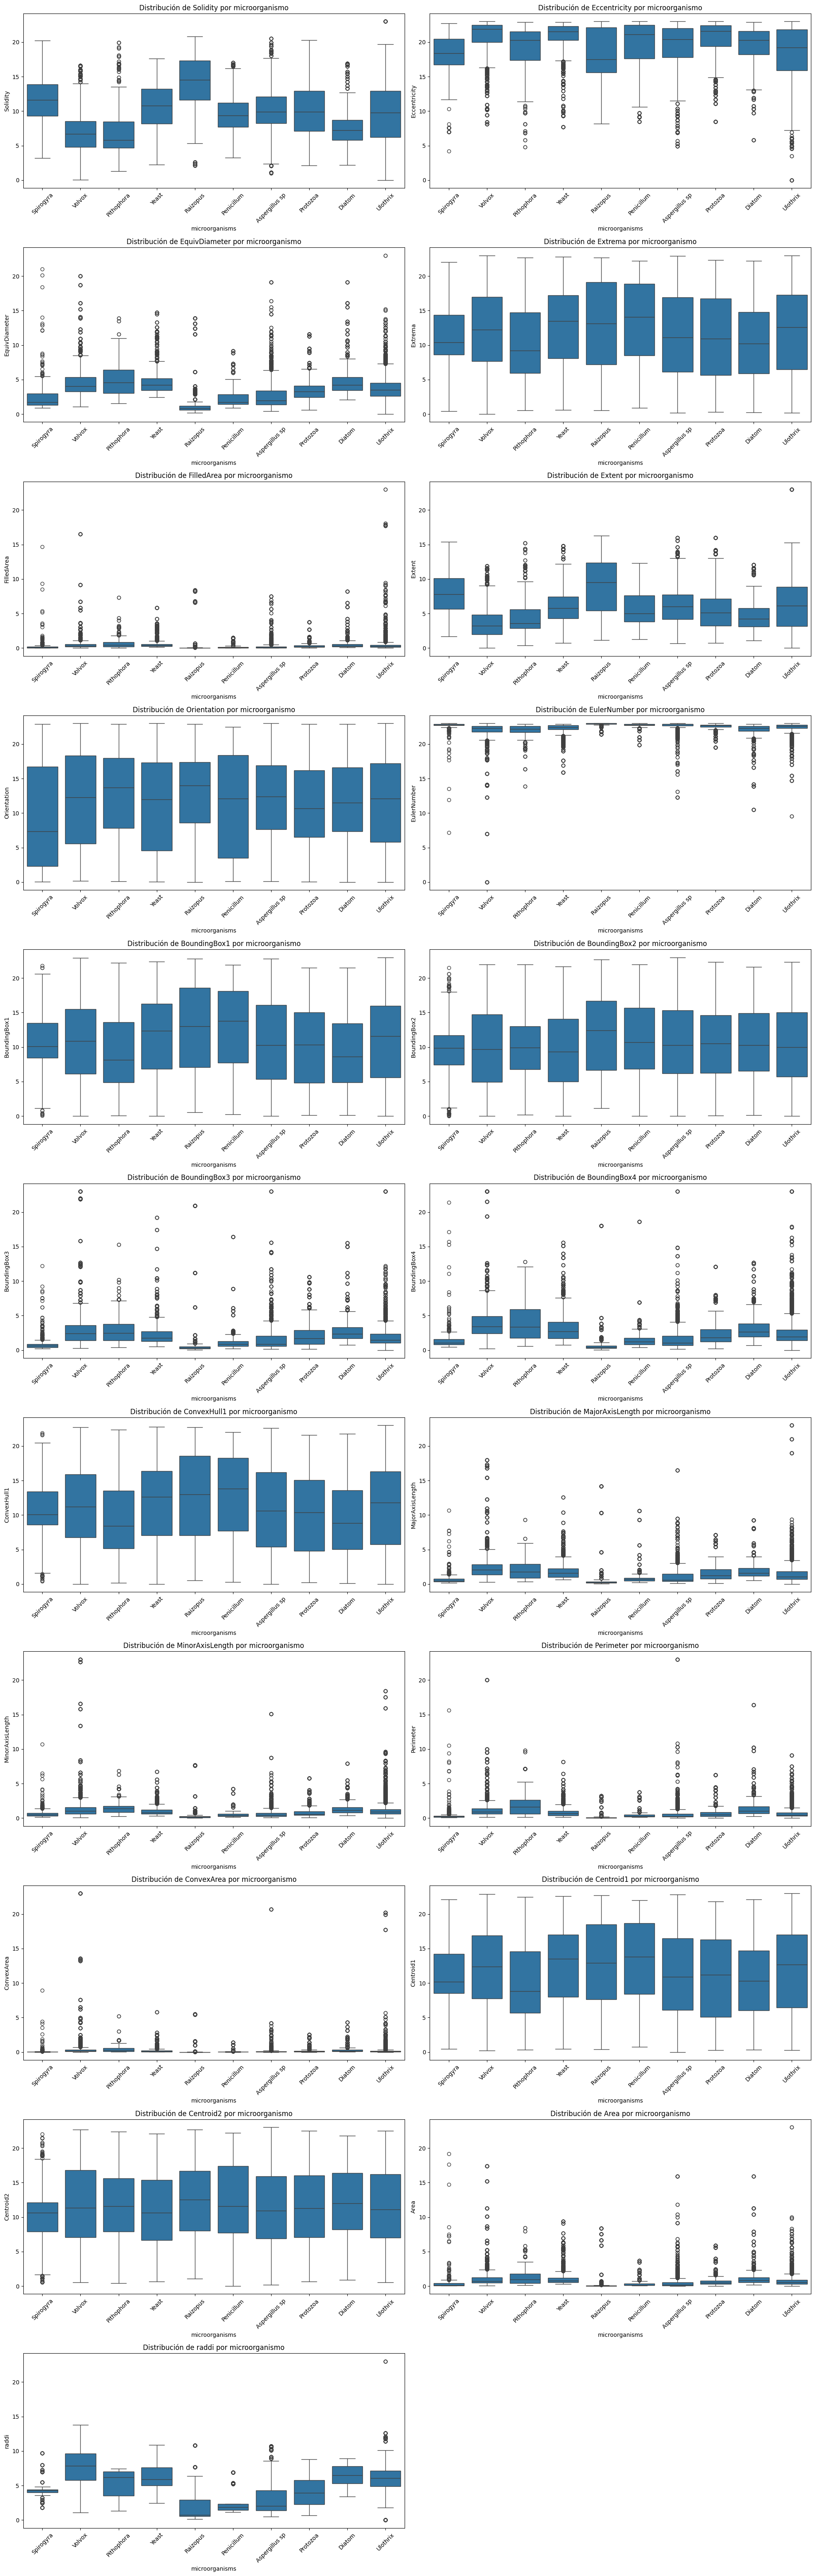

In [11]:
features = ['Solidity', 'Eccentricity', 'EquivDiameter', 'Extrema', 'FilledArea',
       'Extent', 'Orientation', 'EulerNumber', 'BoundingBox1', 'BoundingBox2',
       'BoundingBox3', 'BoundingBox4', 'ConvexHull1', 'MajorAxisLength',
       'MinorAxisLength', 'Perimeter', 'ConvexArea', 'Centroid1', 'Centroid2',
       'Area', 'raddi']
fig, axes = plt.subplots(nrows=len(features)//2 + len(features)%2, ncols=2, figsize=(20, len(features)*3))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='microorganisms', y=feature, ax=axes[i])
    axes[i].set_title(f'Distribución de {feature} por microorganismo')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar el último subplot si el número de features es impar
if len(features) % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()                       

Several features display data points beyond the whiskers of the boxplots. However, given the biological nature of this dataset, these values are not treated as errors or noise, but rather as natural morphological variation within each microorganism class. 
Removing them could eliminate biologically meaningful observations, so they will be retained throughout the analysis.

# PCA

In [12]:

X = df_microbes.drop(columns='microorganisms')
y = df_microbes['microorganisms']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


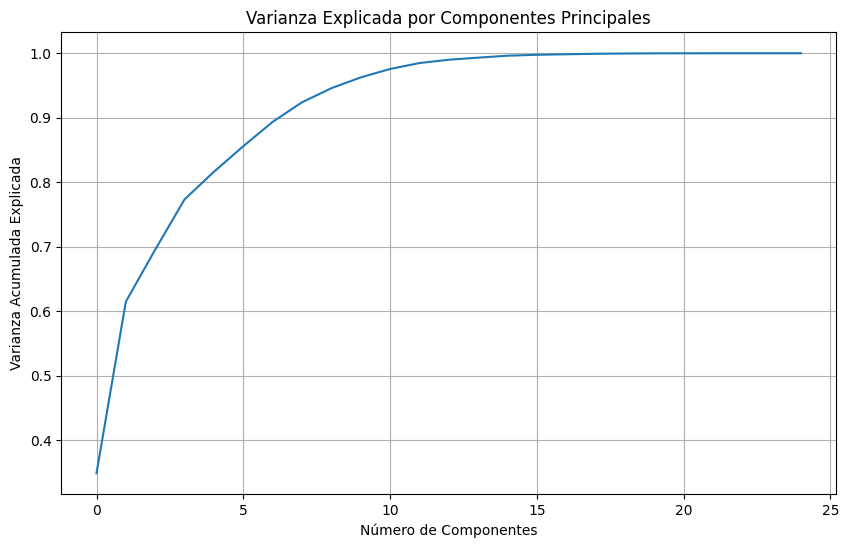

Varianza explicada por los primeros 5 componentes:
Componente 1: 34.89%
Componente 2: 26.60%
Componente 3: 8.06%
Componente 4: 7.79%
Componente 5: 4.28%
Se necesitan 10 componentes para explicar el 95% de la varianza.
Dimensiones de X después de PCA: (30527, 10)


In [13]:


pca_comp = PCA(n_components=None) # n_components=None para ver la varianza explicada por todos los componentes
pca_comp.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_comp.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Explicada por Componentes Principales')
plt.grid(True)
plt.show()

explained_variance = pca_comp.explained_variance_ratio_
print("Varianza explicada por los primeros 5 componentes:")
for i in range(min(5, len(explained_variance))):
    print(f"Componente {i+1}: {explained_variance[i]*100:.2f}%")

num_components_95 = np.where(np.cumsum(explained_variance) >= 0.95)[0][0] + 1
print(f"Se necesitan {num_components_95} componentes para explicar el 95% de la varianza.")

pca_comp = PCA(n_components=num_components_95)
X_pca_comp = pca_comp.fit_transform(X_scaled)

print(f"Dimensiones de X después de PCA: {X_pca_comp.shape}")

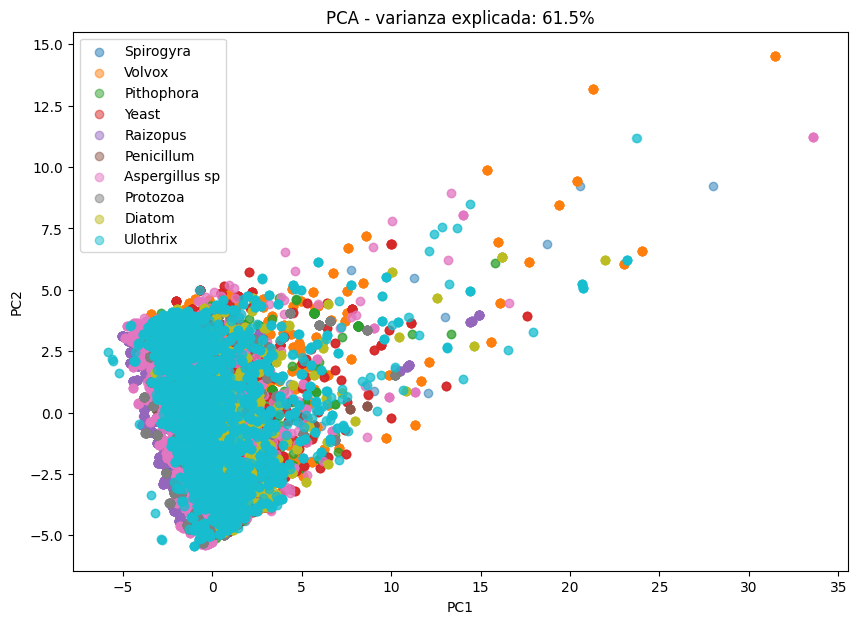

In [14]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)  # X_scaled, no X

plt.figure(figsize=(10, 7))
for clase in y.unique():
    mask = y == clase
    plt.scatter(componentes[mask, 0], componentes[mask, 1], label=clase, alpha=0.5)

plt.legend()
plt.title(f'PCA - varianza explicada: {pca.explained_variance_ratio_.sum():.1%}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

The first two components explain 61.49% of the total variance (PC1: 34.89%, PC2: 26.60%), while the first 
five components accumulate 81.62%.

The 2D projection shows overlap between several classes. This is expected in biological datasets with subtle morphological 
differences between classes, and indicates that a non-linear classification model will be better suited for this problem.